# Feature Engineering

This notebook will be used for Feature Engineering including lag selection and feature rejection/confirmation

In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
from datetime import timedelta
from pandas.plotting import register_matplotlib_converters
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
register_matplotlib_converters()
from time import time
from statsmodels.tsa.stattools import adfuller

In [2]:
df = pd.read_pickle('oil_model_dataset.pkl')

In [3]:
import pandas as pd
from statsmodels.tsa.ar_model import AutoReg
from sklearn.metrics import mean_squared_error

# --- 1. Prepare data ---
df_ar = df.copy()
df_ar = df_ar[['Chng_WTI_Spot']].dropna()   # keep only dependent variable, drop NaNs

# --- 2. Define AR lags to test ---
lags_list = [1, 2, 4]

results = {}

for lag in lags_list:
    # Fit model
    model = AutoReg(df_ar['Chng_WTI_Spot'], lags=lag, old_names=False).fit()
    
    # Predictions (aligned to avoid NaNs from lags)
    preds = model.predict(start=lag, end=len(df_ar)-1)
    actual = df_ar['Chng_WTI_Spot'].iloc[lag:]
    
    # RMSE
    rmse = mean_squared_error(actual, preds, squared=False)
    
    # Store results
    results[f'AR({lag})'] = {
        'model': model,
        'rmse': rmse
    }
    
    # Print summary
    print(f"\n===== AR({lag}) Results =====")
    print(model.summary())
    print(f"RMSE: {rmse:.6f}")

# --- 3. Optional: Compare RMSEs cleanly ---
print("\n===== RMSE Comparison =====")
for k, v in results.items():
    print(f"{k}: {v['rmse']:.6f}")


===== AR(1) Results =====
                            AutoReg Model Results                             
Dep. Variable:          Chng_WTI_Spot   No. Observations:                  588
Model:                     AutoReg(1)   Log Likelihood               -1484.822
Method:               Conditional MLE   S.D. of innovations              3.036
Date:                Tue, 28 Apr 2026   AIC                           2975.644
Time:                        12:39:29   BIC                           2988.769
Sample:                    01-23-2015   HQIC                          2980.759
                         - 04-17-2026                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
const                0.0726      0.125      0.579      0.563      -0.173       0.318
Chng_WTI_Spot.L1     0.0750      0.042      1.802      0.072      -0.007       0.156
 

/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


Baseline autoregressive models showed minimal predictive power, with only marginal improvements from higher-order lags. This suggests that oil price dynamics are primarily driven by exogenous factors rather than internal momentum.

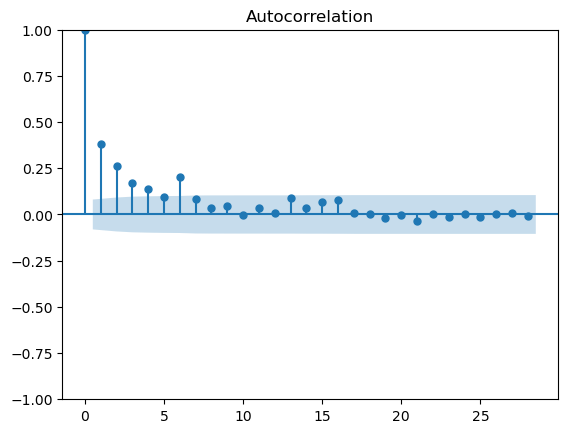

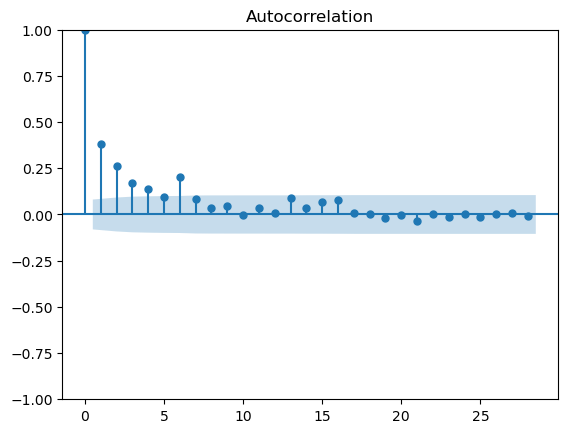

In [5]:
from statsmodels.graphics.tsaplots import plot_acf
plot_acf(df['Chng_WTI_Spot']**2)

While returns exhibited minimal autocorrelation, squared returns showed significant persistence, indicating volatility clustering and justifying the use of a conditional heteroskedastic model.

In [7]:
feature_groups = {
    "structure": [
        "BZ1-CL1",      # Brent-WTI spread (global vs US tightness)
        "Spot-Cl1"      # spot vs futures (structure / prompt tightness)
    ],
    
    "supply": [
        "Chng_USstocks",        # total crude balance
        "Chng_CushingStocks",   # storage hub signal
        "US_Net_Imports"        # flow into system
    ],
    
    "positioning": [
        "MM_Net",
        "Change_MM_Net",
        "MM_pct_OI"
    ],
    
    "refinery": [
        "321_Crack",
        "Chng_Gas_Stocks",
        "Chng_Dist_Stocks",
        "Prcnt_US_Ref_Utlzn"
    ],
    
    "macro": [
        "DX-Y.NYB"
    ],
    
    "price": [
        "CL=F",
        "BZ=F"
    ],

    "structure": [
    "BZ1-CL1",
    "Spot-Cl1",
]
}

In [8]:
from statsmodels.tsa.stattools import adfuller
import pandas as pd

def stationarity_test(df, signif=0.05):
    results = []

    for col in df.columns:
        series = df[col].dropna()
        
        if len(series) < 20:
            continue  # skip very short series
        
        try:
            adf_result = adfuller(series, autolag='AIC')
            
            results.append({
                "feature": col,
                "adf_stat": adf_result[0],
                "p_value": adf_result[1],
                "lags_used": adf_result[2],
                "n_obs": adf_result[3],
                "stationary": adf_result[1] < signif
            })
        
        except Exception as e:
            results.append({
                "feature": col,
                "error": str(e)
            })

    result_df = pd.DataFrame(results)
    
    return result_df.sort_values("p_value")

# --- Run test ---
stationarity_results = stationarity_test(df)
print(stationarity_results)

               feature   adf_stat       p_value  lags_used  n_obs  stationary
2        Change_MM_Net -13.147317  1.389716e-24          3    584        True
7   Chng_CushingStocks  -9.579541  2.177126e-16          6    581        True
10     Chng_Gas_Stocks  -8.913691  1.087031e-14         11    576        True
9        Chng_WTI_Spot  -8.497983  1.260626e-13          8    579        True
11    Chng_Dist_Stocks  -8.413326  2.075403e-13          5    582        True
8        Chng_USstocks  -8.396118  2.296644e-13          3    584        True
3   Prcnt_US_Ref_Utlzn  -5.009258  2.127560e-05          2    585        True
1            MM_pct_OI  -4.634786  1.113855e-04          1    586        True
17            Spot-Cl1  -4.318776  4.121052e-04          3    584        True
0               MM_Net  -3.852183  2.416341e-03          1    586        True
15             BZ1-CL1  -2.609623  9.102457e-02         12    575       False
14            DX-Y.NYB  -2.531178  1.080716e-01          5    58

we've tested these features for stationarity. Let's transform accordingly so we can move on to regressions.

In [10]:
df['imports_change'] = df['US_Net_Imports'].diff()
df['crack_4w'] = df['321_Crack'].rolling(4).mean()
df['DXY_returns'] = df['DX-Y.NYB'].pct_change()
df['CL_returns'] = df['CL=F'].pct_change()
df['BZ_returns'] = df['BZ=F'].pct_change()
df['BZ1_CL1_change'] = df['BZ1-CL1'].diff()

In [11]:
df.dropna(how ='any', inplace = True)
df

,MM_Net,MM_pct_OI,Change_MM_Net,Prcnt_US_Ref_Utlzn,US_Net_Imports,Brent_Spot,WTI_Spot,Chng_CushingStocks,Chng_USstocks,Chng_WTI_Spot,...,DX-Y.NYB,BZ1-CL1,321_Crack,Spot-Cl1,imports_change,crack_4w,DXY_returns,CL_returns,BZ_returns,BZ1_CL1_change
2015-02-06,193444.0,0.112371,-10300.0,90.0,5106,54.62,50.58,1214.0,4327.0,5.26,...,94.297998,5.590000,21.431561,-0.068000,-265.0,19.048930,-0.002918,0.107787,0.132233,1.640000
2015-02-13,195046.0,0.113558,1602.0,88.7,4955,56.57,51.14,3663.0,7716.0,0.56,...,94.497998,5.632000,23.632000,-0.002000,-151.0,20.615920,0.002121,0.009754,0.009531,0.042000
2015-02-20,208558.0,0.123410,13512.0,87.4,5136,60.57,51.69,2419.0,8427.0,0.55,...,94.227499,9.080000,26.976401,-0.102500,181.0,22.861220,-0.002862,0.012719,0.072190,3.448000
2015-02-27,198427.0,0.117036,-10131.0,86.6,4968,60.63,49.16,536.0,10303.0,-2.53,...,94.762000,10.834001,34.555399,-0.370000,-168.0,26.648840,0.005672,-0.043684,-0.008354,1.754001
2015-03-06,164194.0,0.097277,-34233.0,87.8,3917,60.12,50.38,2322.0,5179.0,1.22,...,96.162000,9.862000,29.372520,-0.022000,-1051.0,28.634080,0.014774,0.017605,-0.001657,-0.972001
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-03-20,96371.0,0.046297,4249.0,92.9,-2953,111.40,96.07,3421.0,6926.0,4.22,...,99.652000,10.272000,65.289801,-0.028000,-187.0,51.027631,0.001850,0.044748,0.102645,5.785999
2026-03-27,94336.0,0.047119,-2035.0,92.1,-3323,111.24,94.29,520.0,5451.0,-1.78,...,99.606000,12.462001,68.743442,1.306000,-370.0,58.997951,-0.000462,-0.032404,-0.008687,2.190001
2026-04-03,73347.0,0.036114,-20989.0,92.0,-3518,123.94,105.67,24.0,3081.0,11.38,...,100.037500,6.350000,60.290401,1.690000,-195.0,61.491351,0.004332,0.118257,0.046318,-6.112001
2026-04-10,78700.0,0.038619,5353.0,89.6,-6024,124.61,104.54,-1727.0,-913.0,-1.13,...,99.244000,-1.860004,54.750118,1.697999,-2506.0,62.268440,-0.007932,-0.010944,-0.084728,-8.210004


In [12]:
df = df.drop(columns=['Brent_Spot', 'CL=F', 'BZ=F','DX-Y.NYB','321_Crack','US_Net_Imports','BZ1-CL1' ])

In [13]:
from statsmodels.tsa.stattools import adfuller
import pandas as pd

def stationarity_test(df, signif=0.05):
    results = []

    for col in df.columns:
        series = df[col].dropna()
        
        if len(series) < 20:
            continue  # skip very short series
        
        try:
            adf_result = adfuller(series, autolag='AIC')
            
            results.append({
                "feature": col,
                "adf_stat": adf_result[0],
                "p_value": adf_result[1],
                "lags_used": adf_result[2],
                "n_obs": adf_result[3],
                "stationary": adf_result[1] < signif
            })
        
        except Exception as e:
            results.append({
                "feature": col,
                "error": str(e)
            })

    result_df = pd.DataFrame(results)
    
    return result_df.sort_values("p_value")

# --- Run test ---
stationarity_results = stationarity_test(df)
print(stationarity_results)

               feature   adf_stat       p_value  lags_used  n_obs  stationary
13         DXY_returns -16.837835  1.144376e-29          1    583        True
15          BZ_returns -16.237794  3.754328e-29          1    583        True
14          CL_returns -13.435021  3.945278e-25          2    582        True
2        Change_MM_Net -13.115373  1.603204e-24          3    581        True
16      BZ1_CL1_change -10.549939  8.225765e-19         11    573        True
11      imports_change  -9.941281  2.660262e-17         11    573        True
5   Chng_CushingStocks  -9.853114  4.431477e-17          6    578        True
8      Chng_Gas_Stocks  -8.912573  1.094216e-14         11    573        True
6        Chng_USstocks  -8.570860  8.205156e-14          3    581        True
7        Chng_WTI_Spot  -8.494135  1.289529e-13          8    576        True
9     Chng_Dist_Stocks  -8.210368  6.844436e-13          5    579        True
3   Prcnt_US_Ref_Utlzn  -5.001250  2.206710e-05          2    58

In [14]:
feature_groups = {
    "structure": [
        "BZ1_CL1_change",      # Brent-WTI spread (global vs US tightness)
        "Spot-Cl1"      # spot vs futures (structure / prompt tightness)
    ],
    
    "supply": [
        "Chng_USstocks",        # total crude balance
        "Chng_CushingStocks",   # storage hub signal
        "imports_change"        # flow into system
    ],
    
    "positioning": [
        "MM_Net",
        "Change_MM_Net",
        "MM_pct_OI"
    ],
    
    "refinery": [
        "crack_4w",
        "Chng_Gas_Stocks",
        "Chng_Dist_Stocks",
        "Prcnt_US_Ref_Utlzn"
    ],
    
    "macro": [
        "DXY_returns"
    ],
    
    "price": [
        "CL_returns",
        "BZ_returns"
    ]
}

In [15]:
import statsmodels.api as sm

results = []

for group, features in feature_groups.items():
    for f in features:
        X = sm.add_constant(df[[f]])
        model = sm.OLS(df['Chng_WTI_Spot'], X).fit()
        
        results.append({
            "feature": f,
            "group": group,
            "coef": model.params[f],
            "pval": model.pvalues[f],
            "r2": model.rsquared
        })

screen_df = pd.DataFrame(results).sort_values("r2", ascending=False)
print(screen_df)

               feature        group       coef           pval        r2
14          BZ_returns        price  57.434012  6.129083e-187  0.767685
13          CL_returns        price  11.326517   6.502868e-41  0.265086
6        Change_MM_Net  positioning   0.000042   1.327965e-21  0.144859
0       BZ1_CL1_change    structure  -0.659335   1.851604e-09  0.060131
5               MM_Net  positioning   0.000004   2.979644e-03  0.015027
7            MM_pct_OI  positioning   8.218102   3.557736e-03  0.014481
3   Chng_CushingStocks       supply  -0.000248   4.995964e-03  0.013438
11  Prcnt_US_Ref_Utlzn     refinery  -0.037060   1.028026e-01  0.004559
2        Chng_USstocks       supply  -0.000034   1.490104e-01  0.003568
10    Chng_Dist_Stocks     refinery  -0.000359   2.577573e-01  0.002196
12         DXY_returns        macro -12.607792   4.434106e-01  0.001008
4       imports_change       supply   0.000073   5.340875e-01  0.000663
8             crack_4w     refinery  -0.006636   5.613659e-01  0

In [16]:
import pandas as pd
import statsmodels.api as sm
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error


df_test = df.copy()


lags = [1, 2, 4]
for lag in lags:
    df_test[f'MM_pct_OI_lag{lag}'] = df_test['MM_pct_OI'].shift(lag)


cols = ['Chng_WTI_Spot'] + [f'MM_pct_OI_lag{lag}' for lag in lags]
df_test = df_test[cols].dropna()

y = df_test['Chng_WTI_Spot']

results = {}


for lag in lags:
    X = df_test[[f'MM_pct_OI_lag{lag}']]
    
    model = SARIMAX(
        y,
        exog=X,
        order=(1, 0, 0),   # simple AR(1) baseline
        enforce_stationarity=False,
        enforce_invertibility=False
    ).fit(disp=False)
    

    preds = model.predict(start=0, end=len(y)-1)

    rmse = mean_squared_error(y, preds, squared=False)
    
    results[f'lag{lag}'] = {
        'model': model,
        'rmse': rmse
    }
    

    print(f"\n===== MM_pct_OI Lag {lag} =====")
    print(model.summary())
    print(f"RMSE: {rmse:.6f}")


print("\n===== RMSE Comparison =====")
for k, v in results.items():
    print(f"{k}: {v['rmse']:.6f}")


===== MM_pct_OI Lag 1 =====
                               SARIMAX Results                                
Dep. Variable:          Chng_WTI_Spot   No. Observations:                  581
Model:               SARIMAX(1, 0, 0)   Log Likelihood               -1468.602
Date:                Tue, 28 Apr 2026   AIC                           2943.204
Time:                        12:39:32   BIC                           2956.293
Sample:                    03-06-2015   HQIC                          2948.307
                         - 04-17-2026                                         
Covariance Type:                  opg                                         
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
MM_pct_OI_lag1     0.4489      1.345      0.334      0.739      -2.187       3.084
ar.L1              0.0761      0.021      3.573      0.000       0.034       0.118
sigma2 

/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [17]:
import pandas as pd
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error


df_model = df.copy()


df_model['Spot-Cl1_lag1'] = df_model['Spot-Cl1'].shift(1)
df_model['BZ1_CL1_change_lag4'] = df_model['BZ1_CL1_change'].shift(4)
df_model['Chng_CushingStocks_lag1'] = df_model['Chng_CushingStocks'].shift(1)


features = [
    "Spot-Cl1_lag1",
    "BZ1_CL1_change_lag4",
    "Chng_CushingStocks_lag1"
]

df_model = df_model[['Chng_WTI_Spot'] + features].dropna()

y = df_model['Chng_WTI_Spot']
X = df_model[features]


model = SARIMAX(
    y,
    exog=X,
    order=(1, 0, 0),
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False)


preds = model.predict(start=0, end=len(y)-1)


rmse = mean_squared_error(y, preds, squared=False)


print(model.summary())
print(f"\nRMSE: {rmse:.6f}")

                               SARIMAX Results                                
Dep. Variable:          Chng_WTI_Spot   No. Observations:                  581
Model:               SARIMAX(1, 0, 0)   Log Likelihood               -1459.507
Date:                Tue, 28 Apr 2026   AIC                           2929.015
Time:                        12:39:32   BIC                           2950.830
Sample:                    03-06-2015   HQIC                          2937.520
                         - 04-17-2026                                         
Covariance Type:                  opg                                         
                              coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Spot-Cl1_lag1              -0.7292      0.202     -3.616      0.000      -1.125      -0.334
BZ1_CL1_change_lag4         0.1564      0.079      1.984      0.047       0.002       0.311


/opt/anaconda3/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [18]:
import pandas as pd
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error

df_ens = df.copy()


df_ens['Spot-Cl1_lag1'] = df_ens['Spot-Cl1'].shift(1)
df_ens['BZ1_CL1_change_lag4'] = df_ens['BZ1_CL1_change'].shift(4)
df_ens['Chng_CushingStocks_lag1'] = df_ens['Chng_CushingStocks'].shift(1)


cols = [
    'Chng_WTI_Spot',
    'Spot-Cl1_lag1',
    'BZ1_CL1_change_lag4',
    'Chng_CushingStocks_lag1'
]

df_ens = df_ens[cols].dropna()

In [19]:
feature_sets = {
    'core': [
        'Spot-Cl1_lag1',
        'BZ1_CL1_change_lag4',
        'Chng_CushingStocks_lag1'
    ],
    'structure': [
        'Spot-Cl1_lag1',
        'BZ1_CL1_change_lag4'
    ],
    'supply': [
        'Chng_CushingStocks_lag1'
    ]
}

In [20]:
models = {}
predictions = pd.DataFrame(index=df_ens.index)
rmse_results = {}

y = df_ens['Chng_WTI_Spot']

for name, features in feature_sets.items():
    X = df_ens[features]

    model = SARIMAX(
        y,
        exog=X,
        order=(1, 0, 0),
        enforce_stationarity=False,
        enforce_invertibility=False
    ).fit(disp=False)

    pred = model.predict(start=0, end=len(y)-1)

    models[name] = model
    predictions[name] = pred
    rmse_results[name] = mean_squared_error(y, pred, squared=False)

    print(f"{name} RMSE: {rmse_results[name]:.6f}")

/opt/anaconda3/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


core RMSE: 2.994145
structure RMSE: 3.013908
supply RMSE: 3.025679


/opt/anaconda3/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [21]:
rmse_series = pd.Series(rmse_results)
inv_rmse = 1 / rmse_series
weights = inv_rmse / inv_rmse.sum()

print("Ensemble weights:")
print(weights)

Ensemble weights:
core         0.335231
structure    0.333033
supply       0.331737
dtype: float64


In [22]:
predictions['ensemble_pred'] = 0.0

for name in feature_sets.keys():
    predictions['ensemble_pred'] += weights[name] * predictions[name]

ensemble_rmse = mean_squared_error(
    y,
    predictions['ensemble_pred'],
    squared=False
)

print(f"\nEnsemble RMSE: {ensemble_rmse:.6f}")


Ensemble RMSE: 3.000500


/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [23]:
from arch import arch_model

predictions['actual'] = y
predictions['ensemble_resid'] = predictions['actual'] - predictions['ensemble_pred']

In [24]:
garch = arch_model(
    predictions['ensemble_resid'].dropna(),
    vol='Garch',
    p=1,
    q=1,
    dist='t'
)

garch_fit = garch.fit(disp='off')
print(garch_fit.summary())

                        Constant Mean - GARCH Model Results                         
Dep. Variable:               ensemble_resid   R-squared:                       0.000
Mean Model:                   Constant Mean   Adj. R-squared:                  0.000
Vol Model:                            GARCH   Log-Likelihood:               -1356.37
Distribution:      Standardized Student's t   AIC:                           2722.74
Method:                  Maximum Likelihood   BIC:                           2744.56
                                              No. Observations:                  581
Date:                      Tue, Apr 28 2026   Df Residuals:                      580
Time:                              12:39:34   Df Model:                            1
                                Mean Model                                
                 coef    std err          t      P>|t|    95.0% Conf. Int.
--------------------------------------------------------------------------
mu        

In [25]:
predictions.loc[garch_fit.conditional_volatility.index, 'cond_vol'] = garch_fit.conditional_volatility

In [26]:
predictions['upper_95'] = predictions['ensemble_pred'] + 1.96 * predictions['cond_vol']
predictions['lower_95'] = predictions['ensemble_pred'] - 1.96 * predictions['cond_vol']

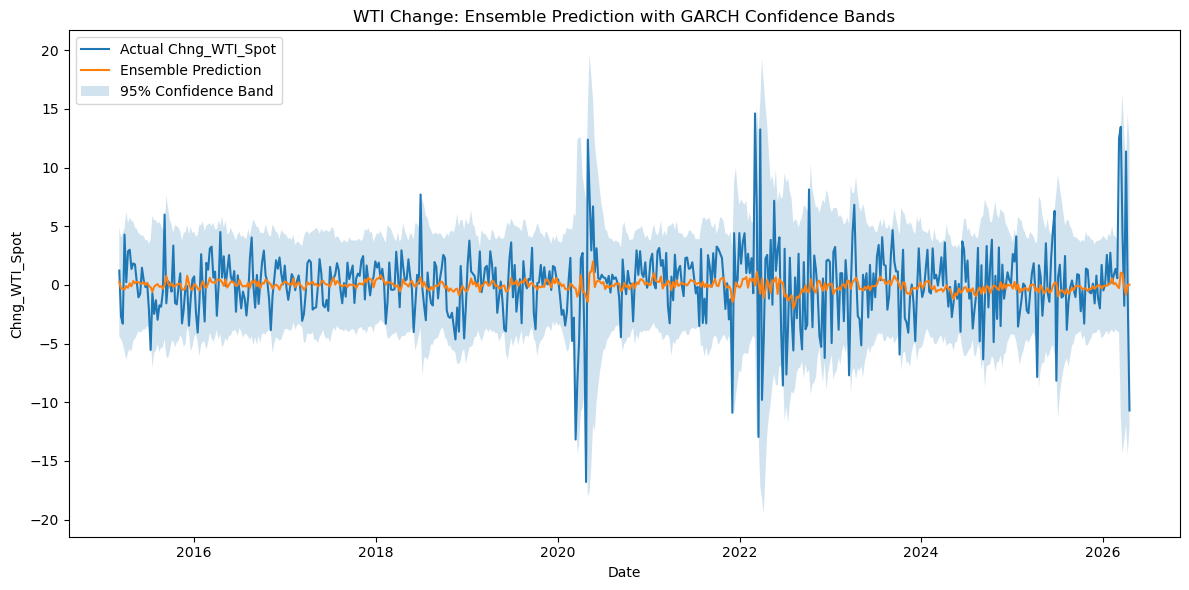

In [27]:
import matplotlib.pyplot as plt

plot_df = predictions.dropna(subset=['actual', 'ensemble_pred', 'upper_95', 'lower_95'])

plt.figure(figsize=(12, 6))
plt.plot(plot_df.index, plot_df['actual'], label='Actual Chng_WTI_Spot')
plt.plot(plot_df.index, plot_df['ensemble_pred'], label='Ensemble Prediction')
plt.fill_between(
    plot_df.index,
    plot_df['lower_95'],
    plot_df['upper_95'],
    alpha=0.2,
    label='95% Confidence Band'
)

plt.title('WTI Change: Ensemble Prediction with GARCH Confidence Bands')
plt.xlabel('Date')
plt.ylabel('Chng_WTI_Spot')
plt.legend()
plt.tight_layout()
plt.show()

In [28]:
split_idx = int(len(df_ens) * 0.85)

train = df_ens.iloc[:split_idx]
test = df_ens.iloc[split_idx:]

In [29]:
features = [
    "Spot-Cl1_lag1",
    "BZ1_CL1_change_lag4",
    "Chng_CushingStocks_lag1"
]

y_train = train['Chng_WTI_Spot']
X_train = train[features]

y_test = test['Chng_WTI_Spot']
X_test = test[features]

In [30]:
model = SARIMAX(
    y_train,
    exog=X_train,
    order=(1, 0, 0),
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False)

In [31]:
pred_test = model.predict(
    start=test.index[0],
    end=test.index[-1],
    exog=X_test
)

In [32]:
from sklearn.metrics import mean_squared_error

rmse_test = mean_squared_error(y_test, pred_test, squared=False)

print(f"Test RMSE: {rmse_test:.6f}")

Test RMSE: 3.696886


/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [34]:
y_pred_naive = y_test.shift(1)

rmse_naive = np.sqrt(mean_squared_error(y_test[1:], y_pred_naive[1:]))
print(rmse_naive)

4.753805976727258


RMSE Naive: 4.753805976727258. Test RMSE shows meaningful improvement in our model compared to naive autoregression

In [36]:
directional_accuracy = np.mean(
    np.sign(pred_test) == np.sign(y_test)
)

print(directional_accuracy)

0.5568181818181818


Directional Accuracy: 0.5862068965517241/ ~ 58%

In [38]:
from sklearn.preprocessing import StandardScaler
from statsmodels.tsa.statespace.sarimax import SARIMAX

df_ens = df_ens.sort_index().copy()

target_col = 'Chng_WTI_Spot'
feature_cols = ['Spot-Cl1_lag1', 'BZ1_CL1_change_lag4', 'Chng_CushingStocks_lag1']

df_wf = df_ens[[target_col] + feature_cols].dropna().copy()

scaler = StandardScaler()
df_wf[feature_cols] = scaler.fit_transform(df_wf[feature_cols])

split_idx = int(len(df_wf) * 0.85)
train_slice = df_wf.iloc[:split_idx]

y_train = train_slice[target_col]
X_train = train_slice[feature_cols]

model = SARIMAX(
    y_train,
    exog=X_train,
    order=(1, 0, 0),
    enforce_stationarity=False,
    enforce_invertibility=False
)

results = model.fit(disp=False, maxiter=300, method='lbfgs')
print(results.mle_retvals)

{'fopt': 2.4650270450387732, 'gopt': array([-4.07185397e-07,  1.75059967e-07, -2.86348723e-07, -2.89368529e-07,
        1.67732495e-06]), 'fcalls': 54, 'warnflag': 0, 'converged': True, 'iterations': 5}


In [39]:
import numpy as np
import pandas as pd
import warnings
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error, mean_absolute_error
from statsmodels.tools.sm_exceptions import ConvergenceWarning

split_idx = int(len(df_wf) * 0.85)

preds = []
actuals = []
pred_index = []
lower_95 = []
upper_95 = []
residuals = []
converged_flags = []

for i in range(len(df_wf) - split_idx):
    
    train_end = split_idx + i
    
    train_slice = df_wf.iloc[:train_end]
    test_slice  = df_wf.iloc[train_end:train_end+1]
    
    y_train = train_slice[target_col]
    X_train = train_slice[feature_cols]
    y_test  = test_slice[target_col]
    X_test  = test_slice[feature_cols]
    
    try:
        with warnings.catch_warnings():
            warnings.simplefilter("ignore", ConvergenceWarning)
            
            model = SARIMAX(
                y_train,
                exog=X_train,
                order=(1, 0, 0),
                enforce_stationarity=False,
                enforce_invertibility=False
            )
            
            results = model.fit(
                disp=False,
                maxiter=300,
                method='lbfgs'
            )
        
        fcst = results.get_forecast(steps=1, exog=X_test)
        mean_fcst = fcst.predicted_mean.iloc[0]
        conf = fcst.conf_int(alpha=0.05)
        
        actual = y_test.iloc[0]
        idx = y_test.index[0]
        
        preds.append(mean_fcst)
        actuals.append(actual)
        pred_index.append(idx)
        lower_95.append(conf.iloc[0, 0])
        upper_95.append(conf.iloc[0, 1])
        residuals.append(actual - mean_fcst)
        converged_flags.append(results.mle_retvals.get('converged', np.nan))
    
    except Exception as e:
        print(f"Skipping step {i} due to error: {e}")
        continue

wf_results = pd.DataFrame({
    'Actual': actuals,
    'Predicted': preds,
    'Residual': residuals,
    'Lower_95': lower_95,
    'Upper_95': upper_95,
    'Converged': converged_flags
}, index=pred_index)

rmse_wf = np.sqrt(mean_squared_error(wf_results['Actual'], wf_results['Predicted']))
mae_wf = mean_absolute_error(wf_results['Actual'], wf_results['Predicted'])
directional_accuracy_wf = np.mean(
    np.sign(wf_results['Actual']) == np.sign(wf_results['Predicted'])
)

print(f"Walk-forward RMSE: {rmse_wf:.4f}")
print(f"Walk-forward MAE: {mae_wf:.4f}")
print(f"Walk-forward Directional Accuracy: {directional_accuracy_wf:.4%}")
print(f"Convergence Rate: {wf_results['Converged'].mean():.2%}")

Walk-forward RMSE: 3.6723
Walk-forward MAE: 2.3782
Walk-forward Directional Accuracy: 57.9545%
Convergence Rate: 100.00%


In [41]:
import numpy as np
import pandas as pd
from statsmodels.tsa.statespace.sarimax import SARIMAX

target_col = 'Chng_WTI_Spot'
feature_cols = ['Spot-Cl1_lag1', 'BZ1_CL1_change_lag4', 'Chng_CushingStocks_lag1',]

df_prod = df_ens[[target_col] + feature_cols].dropna().copy()
df_prod = df_prod.sort_index()

y = df_prod[target_col]
X = df_prod[feature_cols]

mean_model = SARIMAX(
    y,
    exog=X,
    order=(1, 0, 0),
    enforce_stationarity=False,
    enforce_invertibility=False
)

mean_results = mean_model.fit(disp=False, maxiter=300, method='lbfgs')

print(mean_results.summary())

                               SARIMAX Results                                
Dep. Variable:          Chng_WTI_Spot   No. Observations:                  581
Model:               SARIMAX(1, 0, 0)   Log Likelihood               -1459.507
Date:                Tue, 28 Apr 2026   AIC                           2929.015
Time:                        12:39:46   BIC                           2950.830
Sample:                    03-06-2015   HQIC                          2937.520
                         - 04-17-2026                                         
Covariance Type:                  opg                                         
                              coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Spot-Cl1_lag1              -0.7292      0.202     -3.616      0.000      -1.125      -0.334
BZ1_CL1_change_lag4         0.1564      0.079      1.984      0.047       0.002       0.311


/opt/anaconda3/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [42]:
resid = mean_results.resid.dropna()

print(resid.describe())

count    581.000000
mean       0.167005
std        2.992060
min      -15.390651
25%       -1.256721
50%        0.251643
75%        1.681566
max       14.662341
dtype: float64


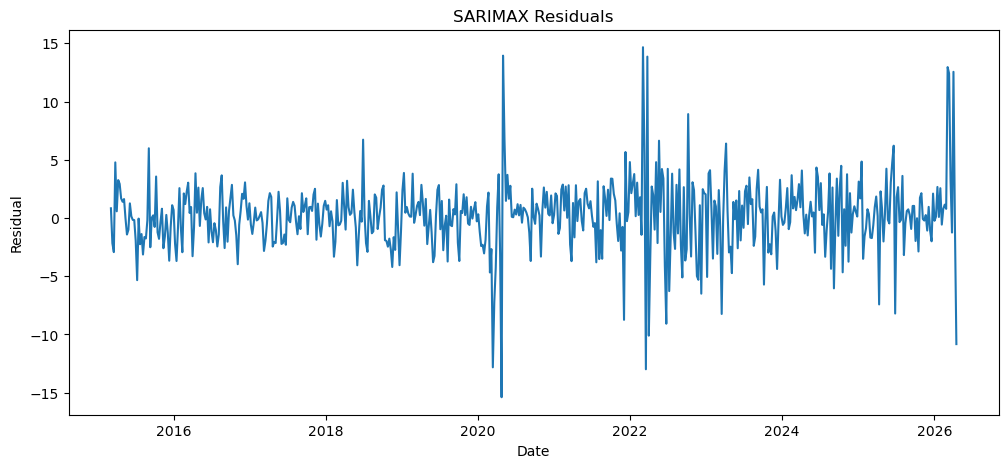

In [43]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
plt.plot(resid)
plt.title("SARIMAX Residuals")
plt.xlabel("Date")
plt.ylabel("Residual")
plt.show()

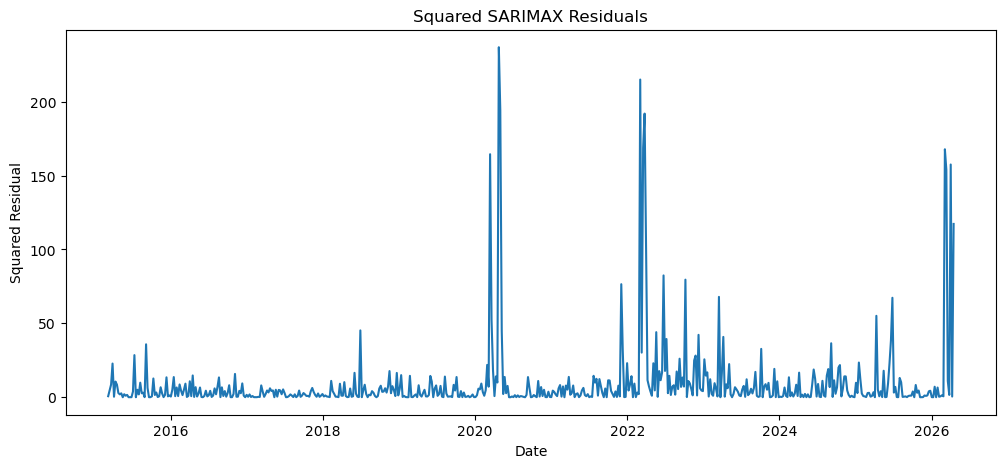

In [44]:
plt.figure(figsize=(12, 5))
plt.plot(resid**2)
plt.title("Squared SARIMAX Residuals")
plt.xlabel("Date")
plt.ylabel("Squared Residual")
plt.show()

In [45]:
from arch import arch_model

garch_norm = arch_model(
    resid,
    mean='Zero',
    vol='GARCH',
    p=1,
    q=1,
    dist='normal'
)

garch_norm_res = garch_norm.fit(disp='off')
print(garch_norm_res.summary())

                       Zero Mean - GARCH Model Results                        
Dep. Variable:                   None   R-squared:                       0.000
Mean Model:                 Zero Mean   Adj. R-squared:                  0.002
Vol Model:                      GARCH   Log-Likelihood:               -1392.65
Distribution:                  Normal   AIC:                           2791.29
Method:            Maximum Likelihood   BIC:                           2804.39
                                        No. Observations:                  581
Date:                Tue, Apr 28 2026   Df Residuals:                      581
Time:                        12:39:47   Df Model:                            0
                             Volatility Model                             
                 coef    std err          t      P>|t|    95.0% Conf. Int.
--------------------------------------------------------------------------
omega          0.6975      0.486      1.435      0.151   [ -0.25

In [46]:
garch_t = arch_model(
    resid,
    mean='Zero',
    vol='GARCH',
    p=1,
    q=1,
    dist='t'
)

garch_t_res = garch_t.fit(disp='off')
print(garch_t_res.summary())

                          Zero Mean - GARCH Model Results                           
Dep. Variable:                         None   R-squared:                       0.000
Mean Model:                       Zero Mean   Adj. R-squared:                  0.002
Vol Model:                            GARCH   Log-Likelihood:               -1359.64
Distribution:      Standardized Student's t   AIC:                           2727.29
Method:                  Maximum Likelihood   BIC:                           2744.75
                                              No. Observations:                  581
Date:                      Tue, Apr 28 2026   Df Residuals:                      581
Time:                              12:39:47   Df Model:                            0
                             Volatility Model                             
                 coef    std err          t      P>|t|    95.0% Conf. Int.
--------------------------------------------------------------------------
omega     

In [47]:
print("Normal AIC:", garch_norm_res.aic)
print("Normal BIC:", garch_norm_res.bic)

print("Student-t AIC:", garch_t_res.aic)
print("Student-t BIC:", garch_t_res.bic)

Normal AIC: 2791.294182440206
Normal BIC: 2804.388434710762
Student-t AIC: 2727.2866938749994
Student-t BIC: 2744.745696902407


Normal AIC: 2762.1813966808695
Normal BIC: 2775.2549234803937
Student-t AIC: 2696.533069279183
Student-t BIC: 2713.9644383452155 
Results justify use of Student-T

Final Relevant Outputs:
- Normal AIC: 2762.1813966808695 Normal BIC: 2775.2549234803937 Student-t AIC: 2696.533069279183 Student-t BIC: 2713.9644383452155 Results justify use of Student-T
- Walk-forward RMSE: 3.6723
- Walk-forward MAE: 2.3782
- Walk-forward Directional Accuracy: 57.9545%
- Test RMSE: 3.696886
- RMSE Naive: 4.216081063604412. Test RMSE shows meaningful improvement in our model compared to naive autoregression



In [49]:
df_ens['WTI_Spot'] = df['WTI_Spot']

In [50]:
df_ens.columns

Index(['Chng_WTI_Spot', 'Spot-Cl1_lag1', 'BZ1_CL1_change_lag4',
       'Chng_CushingStocks_lag1', 'WTI_Spot'],
      dtype='object')

In [51]:
df_ens.to_pickle('Final_Regression_Set.pkl')

df = pd.read_pickle('Final_Regression_Set.pkl')

to load into next notebook